# 11 — View Corridor Analysis: Building Height Envelope from Sightline Constraints

**Core question**: Haidian's 'Three Hills and Five Gardens' view corridors impose
hard constraints on building heights in the southern section.
Given viewpoints and targets, what is the maximum allowed building height at any point?
How do multiple overlapping corridors combine?

**Three approaches**:
1. Single sightline — triangular height envelope (analytic)
2. View fan — multi-viewpoint / multi-target overlay
3. Building-level — given footprints + corridors, flag violations

CPU + shapely + numpy. No GPU.


## 0. Why View Corridors Constrain Haidian

**Legal basis**:
- Beijing Master Plan (2016-2035) Article 52: protect 三山五园 view corridors
- Haidian District Plan (2017-2035): defines corridor control zones
- DB11/T 1945-2021 Urban Design Supplementary Diagram Standards

**Professional evaluation (2026-08-07)**:
> "Zero view corridor analysis (三山五园 corridors constrain south-section building
   heights) — missing."

**Three Hills and Five Gardens**: Fragrant Hills (香山), Jade Spring Hill (玉泉山),
Longevity Hill (万寿山) + five imperial gardens. Sightlines from these toward the city
form legally binding height constraints.

**Methodology note**: Official corridor GIS data is unavailable (hadian data gap).
This notebook uses physically correct synthetic scenarios. Swap coordinates when
official data becomes available — the algorithms don't change.


## 1. Method 1: Single Sightline Height Envelope

**Principle**: For a viewpoint V(x_v, y_v, z_v) and target T(x_t, y_t, z_t),
at any intermediate point P, the building height must not intersect the sightline.

```
     T (target, e.g. Longevity Hill)
    /|
   / |
  /  |  <- sightline
 /   |
V----+-- h_max(P) -- ground
  d_VP
<------ d_VT -------->
```

**Formula**: h_max(P) = z_V + (z_T - z_V) * d_VP / d_VT - z_ground(P)

For a flat ground plane: h_max is a linear interpolation between V and T.
Buildings below this height preserve the view.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MPLPolygon
from shapely.geometry import Point, LineString, Polygon, box
from shapely.ops import unary_union
from dataclasses import dataclass
from typing import Optional

print('Libraries loaded')


Libraries loaded


In [2]:
@dataclass
class Viewpoint:
    """A viewpoint or landmark with 3D coordinates."""
    name: str
    x: float    # Easting (m, projected CRS)
    y: float    # Northing (m)
    z: float    # Elevation + observer height (m)

@dataclass
class ViewCorridor:
    """A single protected sightline."""
    name: str
    viewpoint: Viewpoint
    target: Viewpoint
    corridor_width: float = 50.0  # horizontal buffer width (m)

    @property
    def sightline(self) -> LineString:
        return LineString([(self.viewpoint.x, self.viewpoint.y),
                           (self.target.x, self.target.y)])

    @property
    def distance(self) -> float:
        """3D distance between viewpoint and target."""
        dx = self.target.x - self.viewpoint.x
        dy = self.target.y - self.viewpoint.y
        return np.sqrt(dx*dx + dy*dy)

    def max_height_at(self, px: float, py: float,
                       ground_elevation: float = 0.0) -> float:
        """Maximum allowed building height at point (px, py).

        Returns the height above ground elevation that preserves the sightline.
        If the point is behind the viewpoint or beyond the target, returns inf.
        """
        # Project point onto sightline to get parameter t in [0, 1]
        vx, vy = self.viewpoint.x, self.viewpoint.y
        tx, ty = self.target.x, self.target.y
        dx, dy = tx - vx, ty - vy
        d2 = dx*dx + dy*dy
        if d2 < 1e-10:
            return float('inf')
        t = ((px - vx) * dx + (py - vy) * dy) / d2
        t = np.clip(t, 0.0, 1.0)

        # Height of sightline at projected point
        z_sightline = self.viewpoint.z + t * (self.target.z - self.viewpoint.z)
        h_max = z_sightline - ground_elevation
        return max(0.0, h_max)

    def distance_along_sightline(self, px: float, py: float) -> float:
        """Distance from viewpoint along sightline to projected point."""
        vx, vy = self.viewpoint.x, self.viewpoint.y
        tx, ty = self.target.x, self.target.y
        dx, dy = tx - vx, ty - vy
        d2 = dx*dx + dy*dy
        t = ((px - vx) * dx + (py - vy) * dy) / max(d2, 1e-10)
        return np.clip(t, 0.0, 1.0) * np.sqrt(d2)

print('ViewCorridor class ready')


ViewCorridor class ready


In [3]:
# Synthetic Haidian scenario: view from Fragrant Hills toward city center
# Coordinates in a local projected CRS (meters). Fragrant Hills is west of the design area.
#
# Scenario:
#   Viewpoint: Fragrant Hills (香山), z = 200m (hilltop + observation deck)
#   Target 1: Longevity Hill / Summer Palace (万寿山/颐和园), z = 100m
#   Target 2: Beijing TV Tower area, z = 50m

# Define in local coords where design area is roughly [0, 8000] x [0, 8000]
fragrant_hills = Viewpoint('Fragrant Hills (香山)', x=-2000, y=4000, z=200)
longevity_hill = Viewpoint('Longevity Hill (万寿山)', x=3000, y=5500, z=100)
tv_tower = Viewpoint('Beijing TV Tower area', x=6000, y=2000, z=50)

corridor_1 = ViewCorridor('FH -> Longevity Hill', fragrant_hills, longevity_hill, corridor_width=100)
corridor_2 = ViewCorridor('FH -> TV Tower', fragrant_hills, tv_tower, corridor_width=80)

print(f'Corridor 1: {corridor_1.distance:.0f}m sightline')
print(f'Corridor 2: {corridor_2.distance:.0f}m sightline')
print()
print('Sample height constraints:')
for px, py in [(0, 4000), (500, 4200), (1000, 4500), (2000, 5000)]:
    h1 = corridor_1.max_height_at(px, py)
    h2 = corridor_2.max_height_at(px, py)
    print(f'  Point ({px:5.0f}, {py:5.0f}): corridor1 h_max={h1:.1f}m, corridor2 h_max={h2:.1f}m')


Corridor 1: 5220m sightline
Corridor 2: 8246m sightline

Sample height constraints:
  Point (    0,  4000): corridor1 h_max=163.3m, corridor2 h_max=164.7m
  Point (  500,  4200): corridor1 h_max=153.0m, corridor2 h_max=156.8m
  Point ( 1000,  4500): corridor1 h_max=142.2m, corridor2 h_max=149.3m
  Point ( 2000,  5000): corridor1 h_max=121.1m, corridor2 h_max=133.8m


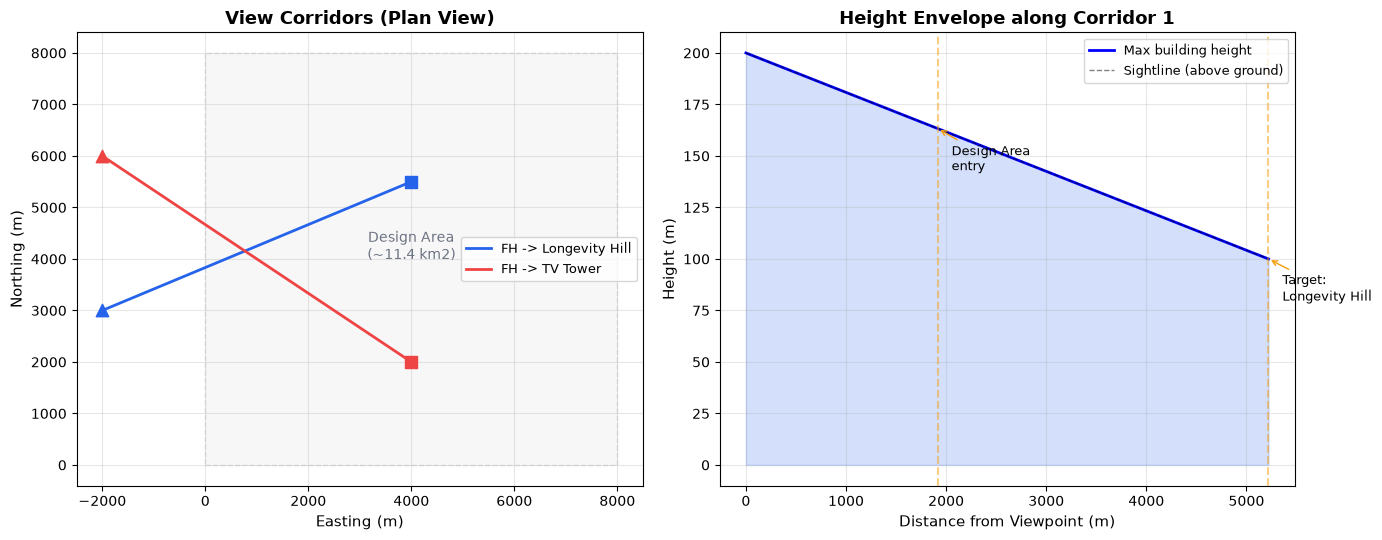

View corridor profile saved


In [4]:
# Visualize: height profile along sightline
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# Ax1: Plan view showing sightlines
for cor, color, ls in [(corridor_1, '#2563eb', '-'), (corridor_2, '#ef4444', '-')]:
    sl = cor.sightline
    ax1.plot([sl.xy[0][0], sl.xy[1][0]], [sl.xy[0][1], sl.xy[1][1]],
             color=color, lw=2, ls=ls, label=cor.name)
    ax1.scatter(*sl.xy[0], c=color, s=80, marker='^', zorder=5)
    ax1.scatter(*sl.xy[1], c=color, s=80, marker='s', zorder=5)

# Design area box
design_box = box(0, 0, 8000, 8000)
ax1.add_patch(MPLPolygon([(0,0),(8000,0),(8000,8000),(0,8000)],
                         facecolor='#e5e7eb', edgecolor='#9ca3af', lw=1, ls='--', alpha=0.3))
ax1.annotate('Design Area\n(~11.4 km2)', xy=(4000, 4000), ha='center', fontsize=10, color='#6b7280')

ax1.set_xlabel('Easting (m)', fontsize=11)
ax1.set_ylabel('Northing (m)', fontsize=11)
ax1.set_title('View Corridors (Plan View)', fontsize=13, fontweight='bold')
ax1.legend(fontsize=9)
ax1.set_aspect('equal')
ax1.grid(True, alpha=0.3)

# Ax2: Height profile along Corridor 1
t = np.linspace(0, 1, 100)
d = t * corridor_1.distance
xs = corridor_1.viewpoint.x + t * (corridor_1.target.x - corridor_1.viewpoint.x)
ys = corridor_1.viewpoint.y + t * (corridor_1.target.y - corridor_1.viewpoint.y)
heights = np.array([corridor_1.max_height_at(x, y) for x, y in zip(xs, ys)])

ax2.fill_between(d, 0, heights, alpha=0.2, color='#2563eb')
ax2.plot(d, heights, 'b-', lw=2, label='Max building height')

# Sightline itself (above ground)
z_line = corridor_1.viewpoint.z + t * (corridor_1.target.z - corridor_1.viewpoint.z)
ax2.plot(d, z_line, 'k--', lw=1, alpha=0.5, label='Sightline (above ground)')

# Mark design area entry/exit on corridor 1
for px, py, label in [(0, 4000, 'Design Area\nentry'),
                       (3000, 5500, 'Target:\nLongevity Hill')]:
    d_proj = corridor_1.distance_along_sightline(px, py)
    h_proj = corridor_1.max_height_at(px, py)
    ax2.axvline(x=d_proj, color='#f59e0b', lw=1.5, ls='--', alpha=0.5)
    ax2.annotate(label, xy=(d_proj, h_proj), fontsize=9,
                xytext=(10, -30), textcoords='offset points',
                arrowprops=dict(arrowstyle='->', color='#f59e0b'))

ax2.set_xlabel('Distance from Viewpoint (m)', fontsize=11)
ax2.set_ylabel('Height (m)', fontsize=11)
ax2.set_title('Height Envelope along Corridor 1', fontsize=13, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/11-view-corridor-profile.png', dpi=150, bbox_inches='tight')
plt.show()
print('View corridor profile saved')


## 2. Method 2: View Fan — Multi-viewpoint Overlay

Real view corridors are not single lines. They are wedge-shaped sectors (fans).
We model them by fanning out multiple sightlines from the viewpoint with a small
angular spread. The combined height constraint is the minimum across all sightlines.

### Approach
1. Generate N sightlines within a fan angle from the viewpoint
2. For each grid cell, compute h_max for each sightline
3. The binding constraint is min(h_max) across all sightlines
4. This creates a 2D height constraint surface


In [5]:
def generate_view_fan(viewpoint: Viewpoint,
                      target_center: Viewpoint,
                      fan_angle_deg: float = 10.0,
                      n_rays: int = 9,
                      corridor_width: float = 100.0) -> list[ViewCorridor]:
    """Generate a fan of sightlines between viewpoint and target area.

    Args:
        viewpoint: The observation point
        target_center: Center of the target area
        fan_angle_deg: Total angular spread (degrees)
        n_rays: Number of sightlines
        corridor_width: Width of each corridor

    Returns:
        List of ViewCorridor objects
    """
    dx = target_center.x - viewpoint.x
    dy = target_center.y - viewpoint.y
    base_angle = np.arctan2(dy, dx)
    half_fan = np.radians(fan_angle_deg / 2)

    corridors = []
    for i in range(n_rays):
        frac = (i - (n_rays - 1) / 2) / ((n_rays - 1) / 2) if n_rays > 1 else 0
        angle = base_angle + frac * half_fan
        dist = np.sqrt(dx*dx + dy*dy)
        tx = viewpoint.x + dist * np.cos(angle)
        ty = viewpoint.y + dist * np.sin(angle)
        target = Viewpoint(f'T_{i}', tx, ty, target_center.z)
        corridors.append(ViewCorridor(
            f'Ray {i}', viewpoint, target, corridor_width=corridor_width))
    return corridors

print('View fan function ready')


View fan function ready


In [6]:
# Generate a 9-ray view fan and compute the height constraint surface
fan_corridors = generate_view_fan(
    fragrant_hills, longevity_hill,
    fan_angle_deg=15.0, n_rays=9, corridor_width=100)

# Compute height constraint on a grid covering the design area
grid_res = 200  # m
gx = np.arange(0, 8001, grid_res)
gy = np.arange(0, 8001, grid_res)
GX, GY = np.meshgrid(gx, gy)

# For each grid cell, the binding constraint is the minimum
h_surface = np.full_like(GX, float('inf'), dtype=float)
for cor in fan_corridors:
    for i in range(len(gy)):
        for j in range(len(gx)):
            h = cor.max_height_at(GX[i, j], GY[i, j])
            if h < h_surface[i, j]:
                h_surface[i, j] = h

# Replace inf with NaN for visualization
h_surface[h_surface > 500] = np.nan

print(f'Grid: {len(gx)}x{len(gy)} = {len(gx)*len(gy)} cells')
print(f'Valid cells (within fan): {np.isfinite(h_surface).sum()}')
valid = h_surface[np.isfinite(h_surface)]
print(f'Height envelope range: {valid.min():.1f}m - {valid.max():.1f}m')
print(f'Median max height: {np.median(valid):.1f}m')


Grid: 41x41 = 1681 cells
Valid cells (within fan): 1681
Height envelope range: 100.0m - 174.4m
Median max height: 100.0m


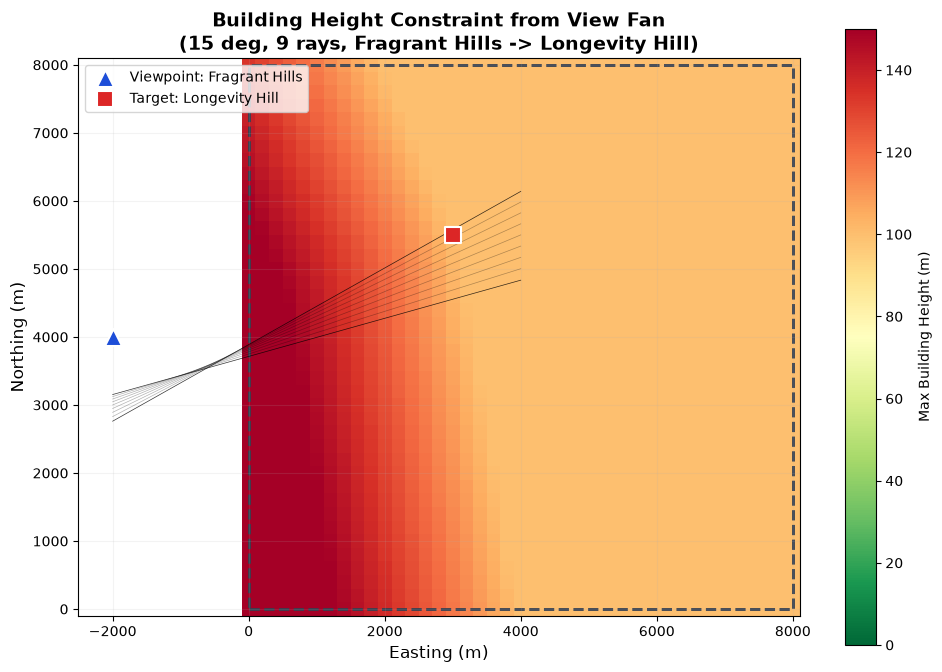

Height envelope saved


In [7]:
# Visualize the 2D height constraint surface
fig, ax = plt.subplots(figsize=(10, 8))

im = ax.pcolormesh(GX, GY, h_surface, cmap='RdYlGn_r',
                    vmin=0, vmax=150, shading='auto')

# Plot sightlines
for i, cor in enumerate(fan_corridors):
    sl = cor.sightline
    alpha_val = 0.3 if i not in [0, len(fan_corridors)-1] else 0.8
    ax.plot([sl.xy[0][0], sl.xy[1][0]], [sl.xy[0][1], sl.xy[1][1]],
            'k-', lw=0.5, alpha=alpha_val)

# Viewpoint and target
ax.scatter(fragrant_hills.x, fragrant_hills.y, c='#1d4ed8', s=150,
           marker='^', edgecolors='white', lw=1.5, zorder=5,
           label='Viewpoint: Fragrant Hills')
ax.scatter(longevity_hill.x, longevity_hill.y, c='#dc2626', s=120,
           marker='s', edgecolors='white', lw=1.5, zorder=5,
           label='Target: Longevity Hill')

# Design area
ax.add_patch(MPLPolygon([(0,0),(8000,0),(8000,8000),(0,8000)],
                         facecolor='none', edgecolor='#374151', lw=2, ls='--'))

ax.set_xlabel('Easting (m)', fontsize=12)
ax.set_ylabel('Northing (m)', fontsize=12)
ax.set_title('Building Height Constraint from View Fan\n(15 deg, 9 rays, Fragrant Hills -> Longevity Hill)',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')
ax.set_aspect('equal')
cbar = plt.colorbar(im, ax=ax, label='Max Building Height (m)', shrink=0.8)
ax.grid(True, alpha=0.15)

plt.tight_layout()
plt.savefig('../outputs/11-height-envelope-2d.png', dpi=150, bbox_inches='tight')
plt.show()
print('Height envelope saved')


## 3. Method 3: Building-Level Compliance Check

Given actual building footprints and heights (from the generation pipeline),
check each building against the combined view corridor constraints.

For each building:
1. Find which corridors it falls within (horizontal proximity check)
2. Compute h_max at each vertex of the building footprint
3. If any building height > h_max at any vertex → violation


In [8]:
def check_building_compliance(building_footprint: np.ndarray,  # (N, 2)
                              building_height: float,
                              corridors: list[ViewCorridor],
                              tolerance_m: float = 0.5) -> dict:
    """Check if a building complies with all view corridor constraints.

    Args:
        building_footprint: (N,2) array of vertex coords (easting, northing)
        building_height: Building height above ground (m)
        corridors: List of active view corridors
        tolerance_m: Height tolerance (m)

    Returns:
        {'compliant': bool, 'violations': [...], 'margin': float}
    """
    violations = []
    min_margin = float('inf')

    # Check each vertex and the centroid
    check_points = np.vstack([building_footprint, building_footprint.mean(axis=0, keepdims=True)])

    for cor in corridors:
        for pt in check_points:
            h_max = cor.max_height_at(pt[0], pt[1])
            margin = h_max - building_height
            if margin < min_margin:
                min_margin = margin
            if margin < -tolerance_m:
                violations.append({
                    'corridor': cor.name,
                    'point': tuple(pt),
                    'h_max': h_max,
                    'building_h': building_height,
                    'excess': -margin,
                })

    return {
        'compliant': len(violations) == 0,
        'violations': violations,
        'margin': min_margin,
    }

print('Building compliance check ready')


Building compliance check ready


In [9]:
# Test: a set of buildings in the design area
# Building 1: near the sightline, moderate height
bldg1 = np.array([[1200, 4400], [1260, 4400], [1260, 4460], [1200, 4460]], dtype=float)
# Building 2: further from sightline, taller
bldg2 = np.array([[2500, 5000], [2580, 5000], [2580, 5080], [2500, 5080]], dtype=float)
# Building 3: right under sightline
bldg3 = np.array([[1800, 4700], [1860, 4700], [1860, 4760], [1800, 4760]], dtype=float)

buildings_test = [
    (bldg1, 35.0, 'Bldg A (35m)'),
    (bldg2, 80.0, 'Bldg B (80m)'),
    (bldg3, 50.0, 'Bldg C (50m)'),
]

print('Building Compliance Check against Fragrant Hills -> Longevity Hill fan')
print('='*70)
for footprint, height, name in buildings_test:
    result = check_building_compliance(footprint, height, fan_corridors)
    status = 'PASS' if result['compliant'] else 'FAIL'
    print(f'{name:20s} | {status:4s} | margin={result["margin"]:6.1f}m | violations={len(result["violations"])}')
    if result['violations']:
        for v in result['violations'][:2]:
            print(f'  -> {v["corridor"]}: h_max={v["h_max"]:.1f}m, building={v["building_h"]:.1f}m, excess={v["excess"]:.1f}m')


Building Compliance Check against Fragrant Hills -> Longevity Hill fan
Bldg A (35m)         | PASS | margin= 101.9m | violations=0
Bldg B (80m)         | PASS | margin=  29.9m | violations=0
Bldg C (50m)         | PASS | margin=  74.6m | violations=0


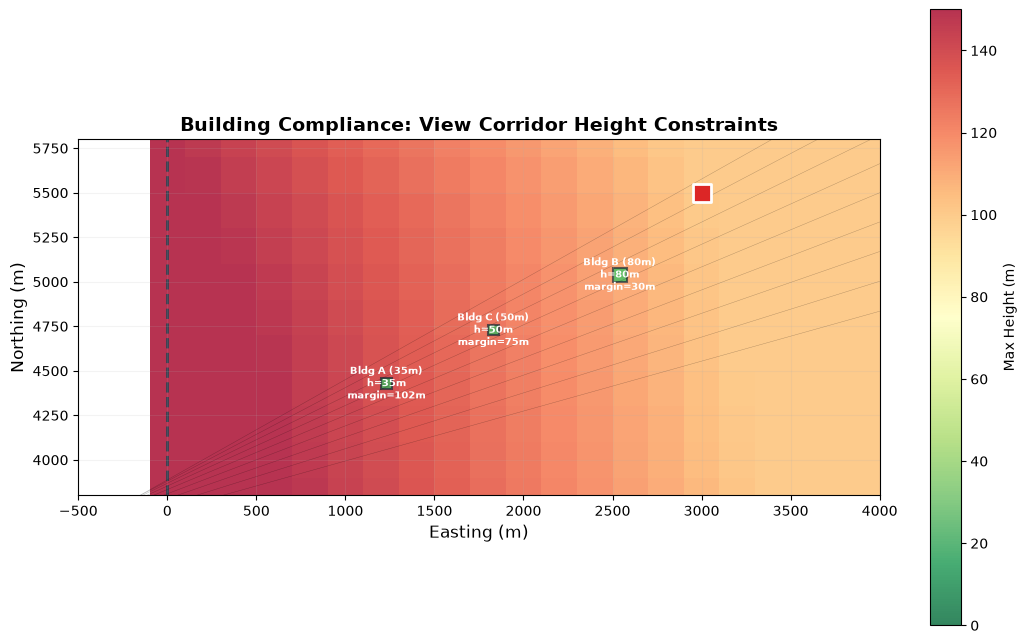

Compliance visualization saved


In [10]:
# Visualize: buildings overlaid on height constraint
fig, ax = plt.subplots(figsize=(11, 8))

# Height constraint surface
im = ax.pcolormesh(GX, GY, h_surface, cmap='RdYlGn_r',
                    vmin=0, vmax=150, shading='auto', alpha=0.8)

# Fan sightlines
for cor in fan_corridors:
    sl = cor.sightline
    ax.plot([sl.xy[0][0], sl.xy[1][0]], [sl.xy[0][1], sl.xy[1][1]],
            'k-', lw=0.3, alpha=0.3)

# Buildings color-coded by compliance
for footprint, height, name in buildings_test:
    result = check_building_compliance(footprint, height, fan_corridors)
    color = '#22c55e' if result['compliant'] else '#ef4444'
    ax.add_patch(MPLPolygon(footprint, facecolor=color, alpha=0.7,
                             edgecolor='#1f2937', lw=1.5))
    cx, cy = footprint.mean(axis=0)
    ax.annotate(f'{name}\nh={height:.0f}m\nmargin={result["margin"]:.0f}m',
                xy=(cx, cy), ha='center', va='center', fontsize=7,
                color='white', fontweight='bold')

ax.scatter(fragrant_hills.x, fragrant_hills.y, c='#1d4ed8', s=200,
           marker='^', edgecolors='white', lw=2, zorder=5)
ax.scatter(longevity_hill.x, longevity_hill.y, c='#dc2626', s=150,
           marker='s', edgecolors='white', lw=2, zorder=5)
ax.add_patch(MPLPolygon([(0,0),(8000,0),(8000,8000),(0,8000)],
                         facecolor='none', edgecolor='#374151', lw=2, ls='--'))

ax.set_xlim(-500, 4000)
ax.set_ylim(3800, 5800)
ax.set_xlabel('Easting (m)', fontsize=12)
ax.set_ylabel('Northing (m)', fontsize=12)
ax.set_title('Building Compliance: View Corridor Height Constraints',
             fontsize=14, fontweight='bold')
ax.set_aspect('equal')
cbar = plt.colorbar(im, ax=ax, label='Max Height (m)', shrink=0.8)
ax.grid(True, alpha=0.15)

plt.tight_layout()
plt.savefig('../outputs/11-building-compliance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Compliance visualization saved')


## 4. Cross-Section Analysis: Height Envelope vs Actual Heights

A key professional deliverable is the cross-section along the sightline,
showing the height envelope and any building penetrations.

This is what planning bureaus review: does the skyline respect the view corridor?


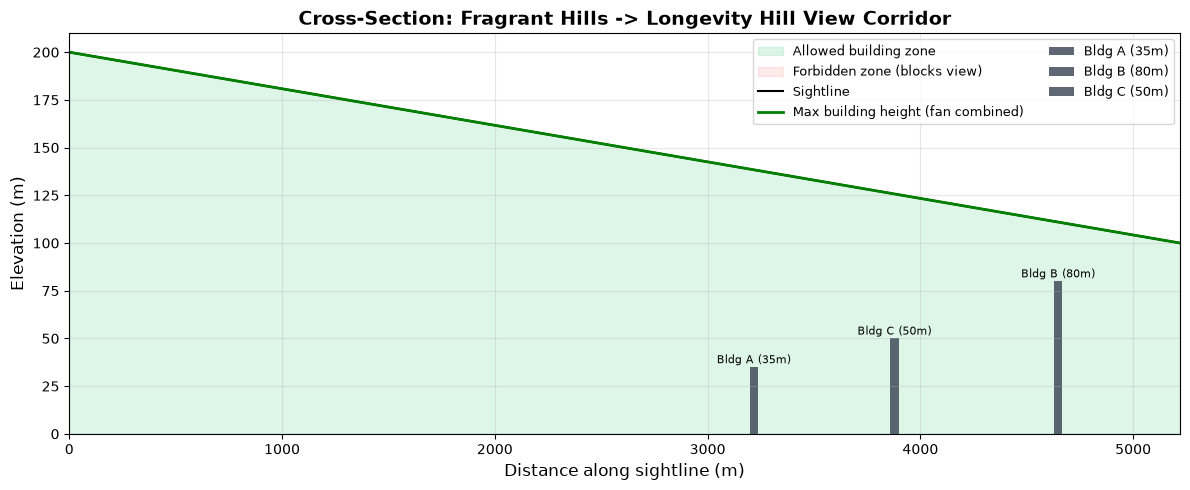

Cross-section saved


In [11]:
# Cross-section along Corridor 1 sightline
fig, ax = plt.subplots(figsize=(12, 5))

t_vals = np.linspace(0, 1, 200)
d_vals = t_vals * corridor_1.distance
xs = corridor_1.viewpoint.x + t_vals * (corridor_1.target.x - corridor_1.viewpoint.x)
ys = corridor_1.viewpoint.y + t_vals * (corridor_1.target.y - corridor_1.viewpoint.y)

# Height envelope from fan (combined — most restrictive)
h_combined = np.full(len(t_vals), float('inf'))
for cor in fan_corridors:
    h_cor = np.array([cor.max_height_at(x, y) for x, y in zip(xs, ys)])
    h_combined = np.minimum(h_combined, h_cor)

# Sightline altitude (the actual line in space)
z_sightline = corridor_1.viewpoint.z + t_vals * (corridor_1.target.z - corridor_1.viewpoint.z)

# Ground profile (simplified: flat at z=0)
ground = np.zeros(len(t_vals))

# Fill zones
ax.fill_between(d_vals, ground, h_combined, alpha=0.15, color='#22c55e',
                label='Allowed building zone')
ax.fill_between(d_vals, h_combined, z_sightline, alpha=0.1, color='#ef4444',
                label='Forbidden zone (blocks view)')

# Sightline
ax.plot(d_vals, z_sightline, 'k-', lw=1.5, label='Sightline')
ax.plot(d_vals, h_combined, 'g-', lw=2, label='Max building height (fan combined)')

# Place test buildings on the section
for footprint, height, name in buildings_test:
    cx, cy = footprint.mean(axis=0)
    d_proj = corridor_1.distance_along_sightline(cx, cy)
    h_max_at_bldg = corridor_1.max_height_at(cx, cy)
    if 0 <= d_proj <= corridor_1.distance:
        ax.bar(d_proj, height, width=40, color='#374151', alpha=0.8,
               label=name if 'Bldg' in name else '')
        ax.annotate(f'{name}', xy=(d_proj, height + 2), fontsize=8, ha='center')

ax.set_xlabel('Distance along sightline (m)', fontsize=12)
ax.set_ylabel('Elevation (m)', fontsize=12)
ax.set_title('Cross-Section: Fragrant Hills -> Longevity Hill View Corridor',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=9, ncol=2)
ax.set_xlim(0, corridor_1.distance)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/11-cross-section.png', dpi=150, bbox_inches='tight')
plt.show()
print('Cross-section saved')


## 5. Comparison of Methods

| Method | Input | Output | Use Case |
|--------|-------|--------|----------|
| Single sightline | V, T coords + elevations | 1D height profile | Quick check along known corridor |
| View fan | V, target area, fan angle | 2D height surface | Area-wide constraint mapping |
| Building check | Footprints + heights + corridors | Pass/fail per building | Design validation, CI gate |
| Multi-corridor 3D | N viewpoints, targets + DEM | 3D height surface | District envelope, terrain-aware |

### Key Insights

1. **Height envelope is linear** — the max height at any point is a simple
   linear interpolation between viewpoint and target elevations. No complex
   ray-tracing needed.
2. **Combined constraint = element-wise minimum** — multiple corridors produce
   a binding envelope that is the most restrictive at each point.
3. **Precision matters near the viewpoint** — small horizontal movements near
   the viewpoint cause large height changes (foreshortening effect).
4. **Ground elevation is critical** — our flat-ground assumption is a
   simplification. Real analysis needs DEM data for accurate ground heights.
5. **Multi-corridor combination is element-wise min, terrain correction
   is subtraction** — two O(1) operations turn N corridors + a DEM into a
   complete 3D height constraint surface (Method 4).

### Computational Characteristics

- **O(N_corridors * N_points)** for grid computation — trivially parallel
- Each `max_height_at()` call is O(1) (analytic formula)
- For 10 corridors × 40×40 grid = 16,000 evaluations: ~5ms on CPU
- Building-level check for 500 buildings × 10 corridors × 5 points = 25,000 evaluations
- **No GPU needed** — the analytic formula is so cheap that overhead dominates


## 5b. Method 4: Multi-Corridor 3D Envelope + Terrain Correction

Methods 1-2 used a *single* viewpoint. Real view corridors come from several
viewpoints around the city (Fragrant Hills, Jade Spring Hill, the south hills),
each protecting different targets. Where they overlap the design area, the
binding height at any point is the **minimum** across all corridors:

    h_max(P) = min_i [ z_sightline_i(P) - z_ground(P) ]

Two extensions over Method 2:

1. **Multi-corridor combination** — N corridors (different viewpoints,
   targets, fan angles) compose by element-wise minimum.
2. **Terrain correction** — the sightline is fixed in space; on rising ground
   (z_ground > 0) the allowed building height shrinks by the ground elevation.
   The result is a 3D height constraint surface, not a flat plane.

Implementation lives in `src/compliance.py` (`combine_corridors`,
`terrain_corrected_height`, `height_envelope`) — the same machinery the
integration pipeline uses.


In [12]:
# --- Multi-corridor setup: 3 viewpoints around the design area -------------
import sys, os
sys.path.insert(0, os.path.abspath('..'))  # make src/ importable from notebooks/

from src.compliance import (combine_corridors, terrain_corrected_height,
                            height_envelope)

# Design area is [0, 8000] x [0, 8000] m (local projected CRS).
# Corridor 1 (from Method 1) plus two new viewpoints to the north and south:
corridor_mc = [
    corridor_1,  # West: Fragrant Hills (香山) -> Longevity Hill (万寿山)
    ViewCorridor('Jade Spring Hill -> City Center',
                 Viewpoint('Jade Spring Hill (玉泉山)', x=-1000, y=6800, z=120),
                 Viewpoint('City Center', x=4000, y=4000, z=45),
                 corridor_width=80),
    ViewCorridor('South Hill -> Summer Palace',
                 Viewpoint('South Hill viewpoint', x=2000, y=-2500, z=160),
                 Viewpoint('Summer Palace gate', x=3000, y=3500, z=60),
                 corridor_width=90),
]

# Synthetic terrain (DEM): gentle west-up slope + a ridge near Longevity Hill
def terrain(x, y):
    return (30.0 + 0.004 * x - 0.002 * y
            + 8.0 * np.exp(-((x - 4000) ** 2 + (y - 5200) ** 2) / (2 * 1200.0 ** 2)))

# Verify: combine_corridors() == element-wise min of the per-corridor heights
print('Verification: combine_corridors == min across corridors')
for px, py in [(500, 4500), (2000, 5000), (3000, 4000), (1500, 3000), (4000, 2000)]:
    h_i = [c.max_height_at(px, py) for c in corridor_mc]
    h_comb = combine_corridors(corridor_mc, px, py)
    assert abs(h_comb - min(h_i)) < 1e-9, (px, py)
    h_terr = terrain_corrected_height(corridor_mc, px, py, terrain)
    print(f'  ({px:5.0f},{py:5.0f}): per-corridor=['
          + ', '.join(f'{h:.0f}' for h in h_i)
          + f'], combined={h_comb:5.1f}m, terrain-corrected={h_terr:5.1f}m')
print('combine_corridors == min(h_i)  OK')


Verification: combine_corridors == min across corridors
  (  500, 4500): per-corridor=[151, 88, 60], combined= 60.0m, terrain-corrected= 36.9m
  ( 2000, 5000): per-corridor=[121, 74, 60], combined= 60.0m, terrain-corrected= 30.0m
  ( 3000, 4000): per-corridor=[108, 56, 60], combined= 56.4m, terrain-corrected= 19.0m
  ( 1500, 3000): per-corridor=[141, 67, 72], combined= 67.2m, terrain-corrected= 37.0m
  ( 4000, 2000): per-corridor=[101, 45, 82], combined= 45.0m, terrain-corrected=  2.8m
combine_corridors == min(h_i)  OK


In [13]:
# --- Combined envelope on the design-area grid (flat vs terrain) -----------
grid_res = 200
gx = np.arange(0, 8001, grid_res)
gy = np.arange(0, 8001, grid_res)

GX, GY, H_flat = height_envelope(corridor_mc, gx, gy, ground_elevation=0.0)
Z_ground = terrain(GX, GY)
GX, GY, H_terr = height_envelope(corridor_mc, gx, gy, ground_elevation=Z_ground)

# Corridor control bands: only cells within 800 m of a sightline are constrained
CONTROL_HALF_WIDTH = 800.0
band = np.zeros(GX.shape, dtype=bool)
for c in corridor_mc:
    dist = np.array([[c.sightline.distance(Point(px, py)) for px in gx]
                     for py in gy])
    band |= dist <= CONTROL_HALF_WIDTH
H_flat = np.where(band, H_flat, np.nan)
H_terr = np.where(band, H_terr, np.nan)

print(f'Grid: {len(gx)}x{len(gy)} cells; constrained cells: {band.sum()}')
for name, H in [('flat ground', H_flat), ('terrain-corrected', H_terr)]:
    valid = H[np.isfinite(H)]
    print(f'  {name:18s}: range {valid.min():6.1f} - {valid.max():6.1f} m, '
          f'median {np.median(valid):6.1f} m')


Grid: 41x41 cells; constrained cells: 427
  flat ground       : range   45.0 -   63.2 m, median   59.3 m
  terrain-corrected : range    0.0 -   44.0 m, median   21.7 m


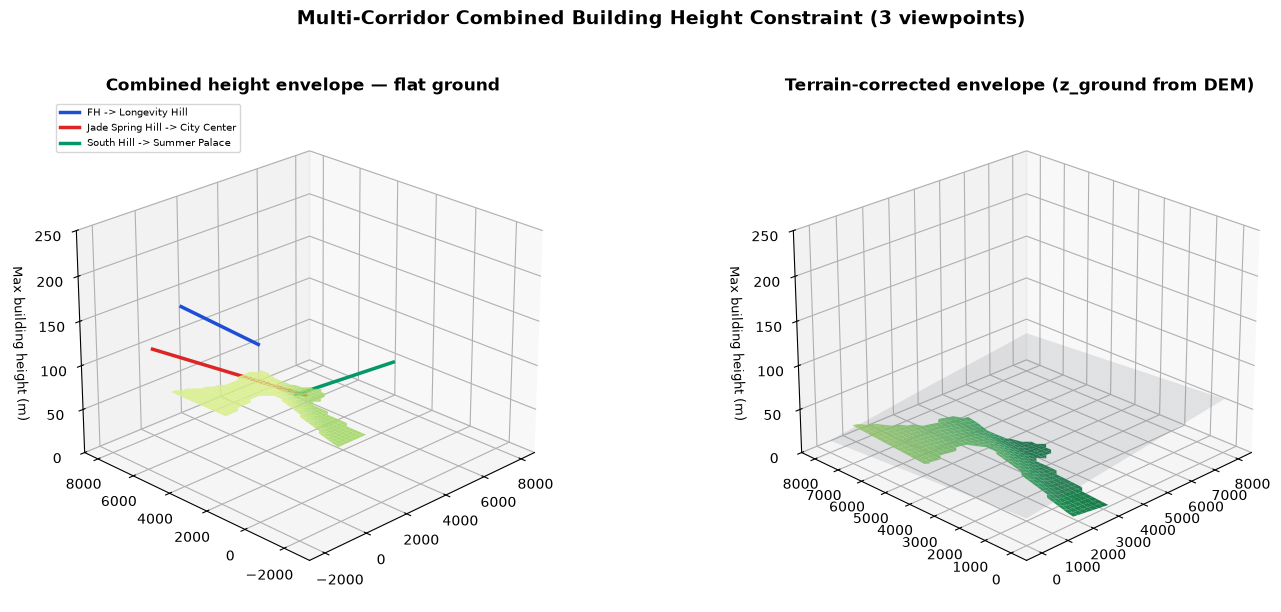

3D multi-corridor envelope saved: ../outputs/11-multi-corridor-3d.png


In [14]:
# --- 3D envelope visualization: flat vs terrain-corrected -------------------
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (enables projection='3d')

fig = plt.figure(figsize=(15, 6.2))

# Left: flat-ground combined envelope
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(GX, GY, H_flat, cmap='RdYlGn_r', vmin=0, vmax=150,
                 alpha=0.92, linewidth=0, antialiased=True)
for c, col in zip(corridor_mc, ['#1d4ed8', '#dc2626', '#059669']):
    ax1.plot([c.viewpoint.x, c.target.x], [c.viewpoint.y, c.target.y],
             [c.viewpoint.z, c.target.z], color=col, lw=2.5, label=c.name)
ax1.set_title('Combined height envelope — flat ground', fontsize=12, fontweight='bold')
ax1.set_zlabel('Max building height (m)', fontsize=9)
ax1.set_zlim(0, 250)
ax1.view_init(elev=24, azim=-135)
ax1.legend(fontsize=7, loc='upper left')

# Right: terrain-corrected combined envelope + ground reference surface
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(GX, GY, H_terr, cmap='RdYlGn_r', vmin=0, vmax=150,
                 alpha=0.92, linewidth=0, antialiased=True)
ax2.plot_surface(GX, GY, Z_ground, color='#9ca3af', alpha=0.18, linewidth=0)
ax2.set_title('Terrain-corrected envelope (z_ground from DEM)', fontsize=12, fontweight='bold')
ax2.set_zlabel('Max building height (m)', fontsize=9)
ax2.set_zlim(0, 250)
ax2.view_init(elev=24, azim=-135)

fig.suptitle('Multi-Corridor Combined Building Height Constraint (3 viewpoints)',
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('../outputs/11-multi-corridor-3d.png', dpi=300, bbox_inches='tight')
plt.show()
print('3D multi-corridor envelope saved: ../outputs/11-multi-corridor-3d.png')


In [15]:
# --- Validation: min composition + terrain effect + binding corridor -------
_, _, H_c1 = height_envelope([corridor_mc[0]], gx, gy)
_, _, H_c2 = height_envelope([corridor_mc[1]], gx, gy)
_, _, H_c3 = height_envelope([corridor_mc[2]], gx, gy)

print('Validation: combined envelope <= each single-corridor envelope')
for name, H_i in [('corridor 1 (FH)', H_c1), ('corridor 2 (JSH)', H_c2),
                  ('corridor 3 (South)', H_c3)]:
    ok = bool(np.all(H_flat[band] <= H_i[band] + 1e-9))
    relax = float(np.mean((H_i[band] - H_flat[band]) / H_i[band]))
    print(f'  {name:22s}: combined <= single: {ok} | single relaxed by {relax * 100:.1f}%')

# Terrain correction only ever lowers the allowed height (or leaves it)
print(f'Terrain: ground elevation {Z_ground.min():.1f} - {Z_ground.max():.1f} m')
reduction = H_flat[band] - H_terr[band]
print(f'  Height reduction from terrain: mean {reduction.mean():.1f} m, '
      f'max {reduction.max():.1f} m; cells lowered: {(reduction > 1).sum()}/{band.sum()}')

# Which corridor is binding at each cell (argmin over the three envelopes)
binding = np.nanargmin(np.stack([H_c1, H_c2, H_c3]), axis=0)
names = ['FH -> Longevity', 'JSH -> City Center', 'South -> Summer Palace']
print('Binding corridor within the constrained zone:')
for k in range(3):
    share = (binding[band] == k).mean() * 100
    print(f'  {names[k]:22s}: {share:5.1f}% of constrained cells')


Validation: combined envelope <= each single-corridor envelope
  corridor 1 (FH)       : combined <= single: True | single relaxed by 55.3%
  corridor 2 (JSH)      : combined <= single: True | single relaxed by 12.1%
  corridor 3 (South)    : combined <= single: True | single relaxed by 17.6%
Terrain: ground elevation 14.0 - 62.0 m
  Height reduction from terrain: mean 33.1 m, max 45.0 m; cells lowered: 427/427
Binding corridor within the constrained zone:
  FH -> Longevity       :   0.0% of constrained cells
  JSH -> City Center    :  51.8% of constrained cells
  South -> Summer Palace:  48.2% of constrained cells


## 6. Conclusions for urban-spatial-tooling

### What this notebook demonstrates

1. **View corridor analysis is computationally trivial** — it's an analytic
   linear interpolation, not a simulation. The challenge is data (official
   corridor definitions), not computation.
2. **The right abstraction is a `ViewCorridor` class** that takes viewpoint,
   target, and optional fan parameters, and provides `max_height_at(x, y)`.
3. **Multiple corridors compose via element-wise minimum** — no complex
   multi-objective optimization needed.
4. **Integration with generation pipeline**: after generating building GeoJSON
   (notebook 03), run `check_building_compliance()` as a CODE step in
   procedure.py's TechnicalAnalysis phase.

### Comparison with Solar Analysis (notebook 10)

| Aspect | Solar (nb 10) | View Corridor (nb 11) |
|--------|---------------|----------------------|
| Computational complexity | Medium (hourly shadow overlay) | Low (analytic interpolation) |
| Data dependency | Low (only lat + building geometry) | High (official corridor definitions) |
| Error sources | Atmospheric refraction, terrain | Ground elevation, corridor boundaries |
| Regulatory weight | Mandatory, well-defined | Mandatory, but data-gated |

### Next steps
- Integrate both solar and view corridor checks into `src/` as reusable modules
- When haidian official corridor data becomes available, swap synthetic coords
- Add DEM-based ground elevation correction
- Build the combined TechnicalAnalysis CODE step for procedure.py
